# Tutorial 2 — QSAR de classificacao (potencial antimalarico)

**Objetivo:** treinar e avaliar criticamente um modelo que classifica moleculas
como ativas ou inativas contra *Plasmodium falciparum*.

**Dados:** `data/tutorial/antimalarico_classificacao.csv` — amostra do recorte
ChEMBL `CHEMBL364` do projeto de pesquisa, com rotulos binarios conservadores.

**Pre-requisito:** [Tutorial 1](01_smiles_rdkit_fingerprints.ipynb). Assumimos
que voce ja sabe o que e um SMILES canonico, um fingerprint de Morgan e uma
serie congenere.

> **Enquadramento honesto.** Isto e um baseline de priorizacao dentro de um
> recorte especifico do ChEMBL, nao um classificador universal de potencial
> antimalarico. A prevalencia de ativos na amostra e alta (~0,77), o que torna a
> acuracia enganosa e o enrichment factor modesto. Essas duas limitacoes sao
> conteudo do tutorial, nao defeitos a esconder.

**Roteiro:**

| Secao | Conteudo |
| --- | --- |
| 1 | Carregamento e o que significa o rotulo |
| 2 | Curadoria basica |
| 3 | Fingerprints |
| 4 | Split aleatorio vs. scaffold split, e a medida de vazamento |
| 5 | Treinamento dos modelos |
| 6 | Validacao cruzada |
| 7 | Matriz de confusao |
| 8 | Metricas de desempenho |
| 9 | Prevalencia, top-k e enrichment factor |
| 10 | Limitacoes e exercicios |


## 0. Setup


In [1]:
# No Colab, descomente as tres linhas abaixo antes de executar.
# !pip install -q -r https://github.com/<usuario>/qsar-ml-tutoriais/raw/main/requirements-colab.txt
# !git clone -q https://github.com/<usuario>/qsar-ml-tutoriais.git
# %cd qsar-ml-tutoriais

from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GroupKFold,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from xgboost import XGBClassifier

RANDOM_STATE = 42
RDLogger.DisableLog("rdApp.*")

CANDIDATOS = [
    Path("../data/tutorial"),
    Path("data/tutorial"),
    Path("qsar-ml-tutoriais/data/tutorial"),
]
DATA_DIR = next((p for p in CANDIDATOS if p.exists()), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Nao encontrei data/tutorial/. Rode o notebook de dentro de notebooks/ "
        "ou da raiz do repositorio clonado."
    )

print("Dados em:", DATA_DIR.resolve())

Dados em: F:\Python\Projetos Pessoais\qsar-ml-tutoriais\data\tutorial


## 1. Carregamento e o que significa o rotulo

O rotulo binario nao caiu do ceu. Ele veio de uma regra explicita aplicada aos
valores de atividade medidos, e entender essa regra e pre-requisito para
interpretar qualquer metrica depois.

A convencao usada no projeto de pesquisa e **conservadora**:

| Valor padronizado | Rotulo |
| --- | --- |
| <= 1.000 nM | **ativo** (1) |
| >= 10.000 nM | **inativo** (0) |
| entre 1.000 e 10.000 nM | **descartado** |

A zona intermediaria e jogada fora de proposito. Moleculas com atividade
moderada sao as mais ambiguas: pequenas variacoes de ensaio mudariam o lado da
fronteira. Incluir essa faixa adicionaria mais ruido do que sinal.

O custo dessa escolha e real e precisa ser dito: o modelo aprende a separar
**extremos**, e por isso tende a parecer melhor do que seria num cenario onde
compostos de potencia intermediaria aparecem.


In [2]:
dados = pd.read_csv(DATA_DIR / "antimalarico_classificacao.csv")

print(f"{len(dados)} moleculas, {dados.shape[1]} colunas\n")
print("Distribuicao de classes:")
contagem = dados["activity_label"].value_counts().rename({0: "inativo", 1: "ativo"})
print(contagem.to_string())
print(f"\nPrevalencia de ativos: {dados['activity_label'].mean():.3f}")

dados.head(3)

4000 moleculas, 7 colunas

Distribuicao de classes:
activity_label
ativo      3096
inativo     904

Prevalencia de ativos: 0.774


,molecule_chembl_id,activity_label,standard_value,standard_units,target_chembl_id,assay_chembl_id,rdkit_canonical_smiles
0,CHEMBL1782163,0,11330.00,nM,CHEMBL364,CHEMBL1785111,CC1(C)N=C(N)N=C(NCCCOc2ccc(Cl)cc2)N1.Cl
1,CHEMBL547245,1,677.75,nM,CHEMBL364,CHEMBL1054503,COc1ccc(CCn2c(=N)c(C(=O)NC3CCCC3)cc3c(=O)n4ccc...
2,CHEMBL5419910,0,899230.00,nM,CHEMBL364,CHEMBL5345197,CCOC(=O)N1CCN(CCNc2ccnc3cc(Cl)ccc23)CC1


In [3]:
# A regra de rotulagem fica visivel nos proprios dados: nenhum ativo acima de
# 1000 nM, nenhum inativo abaixo de 10000 nM, e nada no meio.
print("unidades:", dados["standard_units"].unique().tolist())
maior_ativo = dados.loc[dados["activity_label"] == 1, "standard_value"].max()
menor_inativo = dados.loc[dados["activity_label"] == 0, "standard_value"].min()

print(f"maior valor entre os ATIVOS:   {maior_ativo:>9.0f} nM")
print(f"menor valor entre os INATIVOS: {menor_inativo:>9.0f} nM")

unidades: ['nM']
maior valor entre os ATIVOS:        1000 nM
menor valor entre os INATIVOS:     10000 nM


> **Lição da secao 1.** Antes de treinar, saiba responder: de onde veio o rotulo,
> que faixa foi descartada, e o que isso faz com a dificuldade do problema. Um
> modelo que separa extremos nao e o mesmo que um modelo que ordena potencia.


## 2. Curadoria basica dos dados

Quatro verificacoes que todo dataset QSAR precisa passar antes do treino:

1. **SMILES invalidos** — `MolFromSmiles` devolvendo `None`.
2. **Canonicalizacao** — sem ela, duplicatas passam despercebidas.
3. **Duplicatas** — a mesma molecula contada varias vezes distorce o treino e,
   pior, pode cair nos dois lados do split.
4. **Rotulos conflitantes** — a mesma molecula anotada como ativa em um ensaio e
   inativa em outro.

Estes dados **ja passaram** por essa curadoria no projeto de pesquisa, entao os
contadores vao dar zero. Rode as verificacoes assim mesmo: em dados crus do
ChEMBL elas encontram bastante coisa, e um zero verificado vale mais que uma
suposicao.


In [4]:
dados["mol"] = dados["rdkit_canonical_smiles"].map(Chem.MolFromSmiles)
n_invalidos = dados["mol"].isna().sum()

# Recanonicaliza e compara: se a coluna ja estivesse canonica, nada muda.
validos = dados[dados["mol"].notna()]
canonicos = validos["mol"].map(Chem.MolToSmiles)
n_nao_canonicos = (canonicos.values != validos["rdkit_canonical_smiles"].values).sum()

n_duplicatas = dados["rdkit_canonical_smiles"].duplicated().sum()

# Conflito = mesmo SMILES com mais de um rotulo distinto.
por_molecula = dados.groupby("rdkit_canonical_smiles")["activity_label"]
n_conflitos = (por_molecula.nunique() > 1).sum()

print(f"SMILES invalidos:        {n_invalidos}")
print(f"SMILES nao canonicos:    {n_nao_canonicos}")
print(f"duplicatas canonicas:    {n_duplicatas}")
print(f"rotulos conflitantes:    {n_conflitos}")

SMILES invalidos:        0
SMILES nao canonicos:    3
duplicatas canonicas:    0
rotulos conflitantes:    0


In [5]:
# Aplicar as remocoes mesmo quando o contador e zero mantem o pipeline correto
# se um dia o dado de entrada mudar.
limpos = (
    dados[dados["mol"].notna()]
    .drop_duplicates(subset="rdkit_canonical_smiles")
    .reset_index(drop=True)
)

print(f"{len(dados)} -> {len(limpos)} moleculas apos a limpeza")

4000 -> 4000 moleculas apos a limpeza


## 3. Geracao de fingerprints

Morgan raio=2, 2048 bits — a mesma configuracao do Tutorial 1 e dos dois projetos
de pesquisa. Cada molecula vira uma linha de 2048 zeros e uns.


In [6]:
gerador = AllChem.GetMorganGenerator(radius=2, fpSize=2048)

# Converte a serie de SMILES em matriz (n_moleculas x n_bits).
X = np.zeros((len(limpos), 2048), dtype=np.uint8)
for linha, texto in enumerate(limpos["rdkit_canonical_smiles"]):
    mol = Chem.MolFromSmiles(texto)
    if mol is None:
        raise ValueError(f"SMILES invalido apos a limpeza: {texto}")
    DataStructs.ConvertToNumpyArray(gerador.GetFingerprint(mol), X[linha])

y = limpos["activity_label"].to_numpy()

print("X:", X.shape, "| y:", y.shape)
print(f"densidade media: {X.mean():.2%} dos bits ligados")


X: (4000, 2048) | y: (4000,)
densidade media: 2.49% dos bits ligados


## 4. Split aleatorio vs. scaffold split

Esta e a secao mais importante do tutorial.

Um **split aleatorio** sorteia moleculas para treino e teste. O problema: como
vimos no Tutorial 1, datasets QSAR sao cheios de series congeneres. O sorteio
espalha membros da mesma serie pelos dois lados, e o modelo acaba sendo avaliado
prevendo compostos quase identicos aos que ja viu.

Um **scaffold split** agrupa as moleculas pelo esqueleto Bemis-Murcko e mantem
cada grupo inteiro de um lado so. Nenhum esqueleto do teste aparece no treino.


In [7]:
# Esqueleto Bemis-Murcko de cada molecula, ignorando estereoquimica.
# Moleculas que causam erro interno do RDKit recebem um grupo proprio em vez
# de interromper o processamento - mesma convencao dos projetos de pesquisa.
valores_scaffold = []
for smiles in limpos["rdkit_canonical_smiles"]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        valores_scaffold.append(f"SCAFFOLD_ERROR::{smiles}")
        continue
    try:
        esqueleto = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
    except (RuntimeError, ValueError):
        valores_scaffold.append(f"SCAFFOLD_ERROR::{smiles}")
        continue
    valores_scaffold.append(esqueleto if esqueleto else f"NO_SCAFFOLD::{smiles}")

scaffolds = pd.Series(valores_scaffold, index=limpos.index)

print(f"{scaffolds.nunique()} esqueletos distintos para {len(limpos)} moleculas")
print("\nMaiores series:")
print(scaffolds.value_counts().head(3).to_string())


3002 esqueletos distintos para 4000 moleculas

Maiores series:
c1ccccc1                     64
c1ccc2ncccc2c1               32
c1ccc(Nc2ccnc3ccccc23)cc1    17


O maior grupo e o benzeno — como o Tutorial 1 mostrou, ele nao e uma serie
congenere de verdade, so reune moleculas que tem um anel aromatico como unico
esqueleto. Para o split isso nao e problema: o que importa e que o grupo, seja
ele quimicamente coeso ou nao, **nao se divida** entre treino e teste.


In [8]:
# Separa treino/teste por esqueleto, sem nunca dividir um grupo. Convencao
# adotada: os maiores grupos vao para o TREINO e os menores para o TESTE, que
# e o padrao da literatura (o teste fica com as series raras, o caso
# dificil). Os projetos de pesquisa irmaos preenchem o teste primeiro com os
# maiores grupos - a propriedade essencial (zero esqueletos em comum) vale
# nos dois casos, mas os numeros nao sao comparaveis entre as duas convencoes.
test_size = 0.2

grupos = defaultdict(list)
for posicao, esqueleto in enumerate(scaffolds):
    grupos[esqueleto].append(posicao)

# Ordem deterministica: tamanho decrescente, desempate pelo menor indice.
ordenados = sorted(grupos.values(), key=lambda ids: (-len(ids), min(ids)))

limite_treino = len(scaffolds) - round(len(scaffolds) * test_size)
treino, teste = [], []
for grupo in ordenados:
    if len(treino) + len(grupo) <= limite_treino:
        treino.extend(grupo)
    else:
        teste.extend(grupo)

idx_treino_scaffold = np.array(sorted(treino))
idx_teste_scaffold = np.array(sorted(teste))

idx_treino_aleatorio, idx_teste_aleatorio = train_test_split(
    np.arange(len(y)), test_size=test_size, stratify=y, random_state=RANDOM_STATE
)

n_tr_a, n_te_a = len(idx_treino_aleatorio), len(idx_teste_aleatorio)
n_tr_s, n_te_s = len(idx_treino_scaffold), len(idx_teste_scaffold)

print(f"aleatorio: {n_tr_a} treino / {n_te_a} teste")
print(f"scaffold:  {n_tr_s} treino / {n_te_s} teste")


aleatorio: 3200 treino / 800 teste
scaffold:  3200 treino / 800 teste


### 4.1. Medindo o vazamento

A afirmacao "o split aleatorio vaza informacao" nao precisa ficar no campo da
retorica. Da para medir: **que fracao das moleculas de teste tem um esqueleto que
tambem aparece no treino?**


In [9]:
esqueletos_treino_aleatorio = set(scaffolds.iloc[idx_treino_aleatorio])
vazamento_aleatorio = (
    scaffolds.iloc[idx_teste_aleatorio].isin(esqueletos_treino_aleatorio).mean()
)

esqueletos_treino_scaffold = set(scaffolds.iloc[idx_treino_scaffold])
vazamento_scaffold = (
    scaffolds.iloc[idx_teste_scaffold].isin(esqueletos_treino_scaffold).mean()
)

print("Moleculas de teste cujo esqueleto o modelo JA VIU no treino:")
print(f"  split aleatorio: {vazamento_aleatorio:.1%}")
print(f"  scaffold split:  {vazamento_scaffold:.1%}")


Moleculas de teste cujo esqueleto o modelo JA VIU no treino:
  split aleatorio: 33.0%
  scaffold split:  0.0%


> **Lição da secao 4.** O scaffold split nao e "mais rigoroso" por gosto. Ele
> elimina uma forma concreta e mensuravel de vazamento. Se as duas avaliacoes
> derem resultados muito diferentes, a que vale para estimar generalizacao
> prospectiva e a do scaffold split.


## 5. Treinamento dos modelos

Quatro modelos, treinados nos dois splits:

- **`DummyClassifier`** — sempre responde a classe majoritaria. E o **piso
  obrigatorio**: qualquer modelo precisa supera-lo com folga, e num dataset com
  77% de ativos ele ja acerta 77% das vezes so chutando.
- **`LogisticRegression`** — referencia linear.
- **`RandomForestClassifier`** — o modelo principal dos projetos de pesquisa.
- **`XGBClassifier`** — gradient boosting, frequentemente o mais forte em dados
  tabulares.

Os tres ultimos recebem correcao de desbalanceamento (`class_weight="balanced"`
ou `scale_pos_weight`), para nao ignorarem a classe minoritaria — que aqui e a
dos **inativos**.


In [10]:
peso_positivo = (y == 0).sum() / (y == 1).sum()

print(f"scale_pos_weight = {peso_positivo:.3f}  (inativos / ativos)")


scale_pos_weight = 0.292  (inativos / ativos)


In [11]:
resultados, modelos_treinados = [], {}

for nome_split, (idx_tr, idx_te) in {
    "aleatorio": (idx_treino_aleatorio, idx_teste_aleatorio),
    "scaffold": (idx_treino_scaffold, idx_teste_scaffold),
}.items():
    # Instancias novas a cada split, para nao reaproveitar estado entre eles.
    modelos = {
        "Dummy": DummyClassifier(strategy="most_frequent"),
        "LogReg": LogisticRegression(
            class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE
        ),
        "RandomForest": RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            scale_pos_weight=peso_positivo,
            random_state=RANDOM_STATE,
            n_jobs=1,  # n_jobs=1 mantem o resultado bit a bit reproduzivel
            eval_metric="logloss",
        ),
    }

    for nome_modelo, modelo in modelos.items():
        modelo.fit(X[idx_tr], y[idx_tr])

        # Metricas de classificacao. y_score e a probabilidade da classe ativa.
        y_pred = modelo.predict(X[idx_te])
        y_score_split = modelo.predict_proba(X[idx_te])[:, 1]
        y_teste_split = y[idx_te]
        metricas = {
            "acuracia": (y_pred == y_teste_split).mean(),
            "bal_acuracia": balanced_accuracy_score(y_teste_split, y_pred),
            "precisao": precision_score(y_teste_split, y_pred, zero_division=0),
            "recall": recall_score(y_teste_split, y_pred, zero_division=0),
            "f1": f1_score(y_teste_split, y_pred, zero_division=0),
            "roc_auc": roc_auc_score(y_teste_split, y_score_split),
            "pr_auc": average_precision_score(y_teste_split, y_score_split),
        }

        resultados.append({"split": nome_split, "modelo": nome_modelo, **metricas})
        modelos_treinados[(nome_split, nome_modelo)] = modelo

tabela = pd.DataFrame(resultados)
print("Treinamento concluido:", len(tabela), "combinacoes")


Treinamento concluido: 8 combinacoes


## 6. Validacao cruzada

O conjunto de teste da uma unica estimativa. A validacao cruzada da varias, e a
**dispersao entre elas** informa o quanto aquele numero e estavel.

O detalhe que quase todo tutorial de QSAR erra: uma `StratifiedKFold` comum
reintroduz exatamente o vazamento que o scaffold split eliminou, porque espalha
series congeneres entre os folds. A alternativa correta e `GroupKFold`
**agrupando por esqueleto**.

Vamos rodar as duas sobre o mesmo conjunto de treino e comparar.


In [12]:
X_treino = X[idx_treino_scaffold]
y_treino = y[idx_treino_scaffold]
grupos_treino = scaffolds.iloc[idx_treino_scaffold].to_numpy()

modelo_cv = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)

cv_estratificada = cross_val_score(
    modelo_cv, X_treino, y_treino,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
)
cv_agrupada = cross_val_score(
    modelo_cv, X_treino, y_treino,
    cv=GroupKFold(n_splits=5), groups=grupos_treino, scoring="roc_auc",
)

print("ROC-AUC em validacao cruzada (5 folds):")
print(f"  StratifiedKFold (ingenua):  {cv_estratificada.mean():.3f}"
      f" +/- {cv_estratificada.std():.3f}")
print(f"  GroupKFold por esqueleto:   {cv_agrupada.mean():.3f}"
      f" +/- {cv_agrupada.std():.3f}")
print(f"\n  folds estratificados: {np.round(cv_estratificada, 3)}")
print(f"  folds agrupados:      {np.round(cv_agrupada, 3)}")

ROC-AUC em validacao cruzada (5 folds):
  StratifiedKFold (ingenua):  0.888 +/- 0.012
  GroupKFold por esqueleto:   0.851 +/- 0.012

  folds estratificados: [0.897 0.879 0.874 0.887 0.905]
  folds agrupados:      [0.831 0.853 0.852 0.854 0.867]


> **Lição da secao 6.** A CV agrupada costuma dar media menor e desvio maior. Os
> dois efeitos sao informativos: a media cai porque o vazamento sumiu, e o desvio
> cresce porque grupos quimicos diferentes tem dificuldades diferentes. Reportar
> so a CV ingenua e reportar um numero otimista com falsa precisao.


## 7. Matriz de confusao

A matriz mostra **como** o modelo erra, o que a acuracia esconde. Em triagem
virtual os dois erros tem custos bem diferentes:

- **Falso negativo** — um composto ativo classificado como inativo. Ele sai da
  lista e provavelmente nunca sera testado. E o erro caro.
- **Falso positivo** — um inativo que entra na lista. Custa um ensaio
  desperdicado.


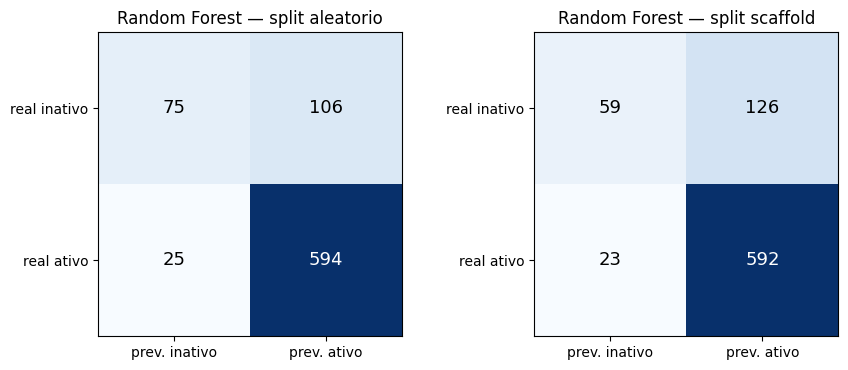

In [13]:
figura, eixos = plt.subplots(1, 2, figsize=(9, 3.8))

for eixo, nome_split, (idx_tr, idx_te) in zip(
    eixos,
    ["aleatorio", "scaffold"],
    [
        (idx_treino_aleatorio, idx_teste_aleatorio),
        (idx_treino_scaffold, idx_teste_scaffold),
    ],
):
    modelo = modelos_treinados[(nome_split, "RandomForest")]
    matriz = confusion_matrix(y[idx_te], modelo.predict(X[idx_te]))

    eixo.imshow(matriz, cmap="Blues")
    for i in range(2):
        for j in range(2):
            eixo.text(
                j, i, f"{matriz[i, j]}", ha="center", va="center",
                color="white" if matriz[i, j] > matriz.max() / 2 else "black",
                fontsize=13,
            )
    eixo.set_xticks([0, 1], ["prev. inativo", "prev. ativo"])
    eixo.set_yticks([0, 1], ["real inativo", "real ativo"])
    eixo.set_title(f"Random Forest — split {nome_split}")

figura.tight_layout()
plt.show()

In [14]:
# Os mesmos numeros, nomeados.
for nome_split, (idx_tr, idx_te) in {
    "aleatorio": (idx_treino_aleatorio, idx_teste_aleatorio),
    "scaffold": (idx_treino_scaffold, idx_teste_scaffold),
}.items():
    modelo = modelos_treinados[(nome_split, "RandomForest")]
    tn, fp, fn, tp = confusion_matrix(y[idx_te], modelo.predict(X[idx_te])).ravel()
    print(f"split {nome_split:<10} VN={tn:>4}  FP={fp:>4}  FN={fn:>4}  VP={tp:>4}")

split aleatorio  VN=  75  FP= 106  FN=  25  VP= 594
split scaffold   VN=  59  FP= 126  FN=  23  VP= 592


## 8. Metricas de desempenho

Cada metrica responde a uma pergunta diferente:

| Metrica | Pergunta |
| --- | --- |
| Acuracia | que fracao das predicoes esta certa? |
| Balanced accuracy | media do acerto em cada classe — imune ao desbalanceamento |
| Precisao | dos que chamei de ativo, quantos eram? |
| Recall | dos ativos que existiam, quantos achei? |
| F1 | media harmonica de precisao e recall |
| ROC-AUC | o modelo ordena ativos acima de inativos? |
| PR-AUC | idem, mas focado na classe positiva |

Com 77% de ativos, a **acuracia e a metrica mais enganosa da lista**: o `Dummy`
consegue 0,77 sem aprender nada. Compare sempre contra esse piso.


In [15]:
formatada = tabela.set_index(["split", "modelo"]).round(3)
formatada

acuracia  bal_acuracia  precisao  recall     f1  \
split     modelo                                                          
aleatorio Dummy            0.774         0.500     0.774   1.000  0.872   
          LogReg           0.804         0.734     0.882   0.861  0.872   
          RandomForest     0.836         0.687     0.849   0.960  0.901   
          XGBoost          0.809         0.779     0.912   0.834  0.871   
scaffold  Dummy            0.769         0.500     0.769   1.000  0.869   
          LogReg           0.768         0.682     0.855   0.841  0.848   
          RandomForest     0.814         0.641     0.825   0.963  0.888   
          XGBoost          0.786         0.736     0.885   0.829  0.856   

                        roc_auc  pr_auc  
split     modelo                         
aleatorio Dummy           0.500   0.774  
          LogReg          0.853   0.951  
          RandomForest    0.884   0.958  
          XGBoost         0.865   0.957  
scaffold  Dummy           0.500   0.769  
          LogReg          0.786   0.921  
          RandomForest    0.854   0.951  
          XGBoost         0.816   0.937

In [16]:
# O contraste que importa: quanto cada modelo perde ao sair do split aleatorio.
comparacao = (
    tabela.pivot(index="modelo", columns="split", values="roc_auc")
    .loc[["Dummy", "LogReg", "RandomForest", "XGBoost"]]
)
comparacao["queda"] = comparacao["aleatorio"] - comparacao["scaffold"]

print("ROC-AUC por split:")
print(comparacao.round(3).to_string())

ROC-AUC por split:
split         aleatorio  scaffold  queda
modelo                                  
Dummy             0.500     0.500  0.000
LogReg            0.853     0.786  0.067
RandomForest      0.884     0.854  0.031
XGBoost           0.865     0.816  0.049


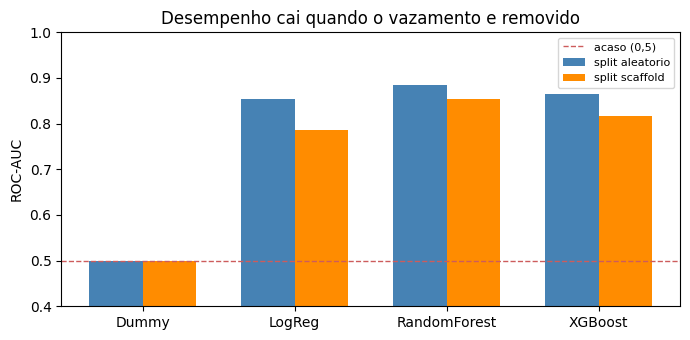

In [17]:
figura, eixo = plt.subplots(figsize=(7, 3.5))

modelos_ordem = ["Dummy", "LogReg", "RandomForest", "XGBoost"]
posicoes = np.arange(len(modelos_ordem))
largura = 0.35

barras = [
    (-largura / 2, "aleatorio", "steelblue"),
    (largura / 2, "scaffold", "darkorange"),
]

for deslocamento, split, cor in barras:
    valores = [
        tabela[(tabela["modelo"] == m) & (tabela["split"] == split)]["roc_auc"].iloc[0]
        for m in modelos_ordem
    ]
    eixo.bar(
        posicoes + deslocamento, valores, largura, label=f"split {split}", color=cor
    )

eixo.axhline(0.5, color="indianred", linestyle="--", linewidth=1, label="acaso (0,5)")
eixo.set_xticks(posicoes, modelos_ordem)
eixo.set_ylabel("ROC-AUC")
eixo.set_ylim(0.4, 1.0)
eixo.set_title("Desempenho cai quando o vazamento e removido")
eixo.legend(fontsize=8)

figura.tight_layout()
plt.show()


> **Lição da secao 8.** Um numero de desempenho sem o split que o produziu nao
> significa nada. Reporte sempre o par, e sempre com o piso do `Dummy` na mesma
> tabela.


## 9. Prevalencia, top-k e enrichment factor

Em triagem virtual voce nao usa o modelo para rotular tudo. Voce ordena a
biblioteca pela probabilidade predita e testa experimentalmente so o topo da
lista. As metricas que importam mudam:

- **precision@top-k** — dos k primeiros, quantos sao ativos de verdade;
- **recall@top-k** — que fracao dos ativos existentes caiu no topo;
- **enrichment factor (EF)** — `precision@k / prevalencia de ativos`. Quantas
  vezes o modelo e melhor que sortear ao acaso.

O EF tem uma propriedade que confunde muita gente: ele depende da **prevalencia**
do conjunto avaliado. Com 77% de ativos, o teto teorico do EF ja e apenas
`1 / 0,77 = 1,3` — nao ha como um modelo, por melhor que seja, mostrar
enriquecimento alto aqui.


In [18]:
modelo_final = modelos_treinados[("scaffold", "RandomForest")]
y_teste = y[idx_teste_scaffold]
y_score = modelo_final.predict_proba(X[idx_teste_scaffold])[:, 1]

prevalencia = y_teste.mean()
print(f"prevalencia de ativos no teste: {prevalencia:.3f}")
print(f"EF maximo teoricamente possivel: {1 / prevalencia:.2f}")

prevalencia de ativos no teste: 0.769
EF maximo teoricamente possivel: 1.30


In [19]:
linhas_topo = []
for fracao in [0.01, 0.05, 0.10, 0.25]:
    # precision@k, recall@k e enrichment factor no topo do ranking.
    k = max(1, int(round(len(y_score) * fracao)))
    topo = np.argsort(y_score)[::-1][:k]
    ativos_no_topo = y_teste[topo].sum()
    precisao = ativos_no_topo / k
    linhas_topo.append({
        "fracao": f"top {fracao:.0%}",
        "k": k,
        "precision@k": precisao,
        "recall@k": ativos_no_topo / y_teste.sum(),
        "EF": precisao / y_teste.mean(),
    })

topo = pd.DataFrame(linhas_topo).set_index("fracao")
topo.round(3)


,k,precision@k,recall@k,EF
fracao,,,,
top 1%,8,1.000,0.013,1.301
top 5%,40,1.000,0.065,1.301
top 10%,80,1.000,0.130,1.301
top 25%,200,0.995,0.324,1.294


### 9.1. O que acontece quando a prevalencia e realista

Uma campanha de triagem real testa uma biblioteca onde ativos sao **raros** —
tipicamente bem menos de 1%. Vamos simular isso reduzindo a proporcao de ativos
no conjunto de teste e recalculando o EF com o **mesmo modelo, sem retreinar**.


In [20]:
gerador_aleatorio = np.random.default_rng(RANDOM_STATE)
indices_ativos = np.where(y_teste == 1)[0]
indices_inativos = np.where(y_teste == 0)[0]

linhas = []
for alvo in [0.774, 0.50, 0.25, 0.10, 0.05]:
    # Mantem todos os inativos e sorteia quantos ativos forem precisos.
    n_ativos = int(round(len(indices_inativos) * alvo / (1 - alvo)))
    n_ativos = min(n_ativos, len(indices_ativos))
    sorteados = gerador_aleatorio.choice(indices_ativos, n_ativos, replace=False)
    escolhidos = np.concatenate([sorteados, indices_inativos])

    y_verdadeiro_sub = y_teste[escolhidos]
    y_score_sub = y_score[escolhidos]

    # precision@10% e enrichment factor no topo do ranking, apos reamostrar a
    # prevalencia.
    fracao = 0.10
    k = max(1, int(round(len(y_score_sub) * fracao)))
    topo = np.argsort(y_score_sub)[::-1][:k]
    ativos_no_topo = y_verdadeiro_sub[topo].sum()
    precisao = ativos_no_topo / k

    linhas.append({
        "prevalencia": y_verdadeiro_sub.mean(),
        "n_ativos": n_ativos,
        "n_total": len(escolhidos),
        "precision@10%": precisao,
        "EF@10%": precisao / y_verdadeiro_sub.mean(),
    })

pd.DataFrame(linhas).round(3)


,prevalencia,n_ativos,n_total,precision@10%,EF@10%
0,0.769,615,800,1.000,1.301
1,0.500,185,370,1.000,2.000
2,0.251,62,247,0.920,3.665
3,0.102,21,206,0.524,5.138
4,0.051,10,195,0.250,4.875


O EF sobe de ~1,3 para ~5,6 conforme a prevalencia cai, **sem o modelo mudar em
nada**. Isso e a prova de que EF nao e uma propriedade do modelo isolado: e uma
propriedade do par (modelo, biblioteca avaliada).

Repare que a **ultima linha quebra a tendencia** e o EF cai. Nao e um erro de
conta: com prevalencia de ~5% sobraram apenas 10 ativos, e o `top 10%` desse
conjunto tem 20 posicoes. Bastam dois ou tres ativos a mais ou a menos no topo
para o numero balancar. A propria tabela esta mostrando o limite da sua
confiabilidade — e reconhecer isso vale mais que apresentar uma curva bonita.

Duas ressalvas honestas sobre a tabela acima:

1. as linhas de prevalencia baixa tem **poucos ativos**, entao a estimativa fica
   ruidosa — o numero de ativos esta na coluna `n_ativos` justamente para voce
   poder desconfiar;
2. simular prevalencia baixa descartando ativos **nao e** o mesmo que triar uma
   biblioteca real, onde os inativos sao quimicamente muito mais diversos. O
   projeto de pesquisa irmao faz a versao correta, coletando decoys de alvos
   nao-*Plasmodium*.

> **Lição da secao 9.** Ao reportar enrichment factor, informe sempre a
> prevalencia do conjunto. EF sem prevalencia e um numero sem unidade.


## 10. Limitacoes e leitura critica

O que este modelo **e**: um baseline reproduzivel de priorizacao dentro do recorte
ChEMBL coletado, dominado por *P. falciparum*.

O que ele **nao e**: um detector universal de potencial antimalarico.

Limitacoes que precisam acompanhar qualquer conclusao:

- **Recorte estreito.** As metricas medem desempenho no recorte `CHEMBL364`. Nada
  aqui sustenta extrapolacao para outros alvos ou parasitas.
- **Rotulo por extremos.** A zona de 1.000–10.000 nM foi descartada; o problema
  real, com compostos de potencia intermediaria, e mais dificil.
- **Prevalencia irrealista.** 77% de ativos nao e uma biblioteca de triagem.
- **Series congeneres dominam.** Como o Tutorial 1 mostrou, o dataset e
  concentrado em poucas familias quimicas; o modelo aprende bem essas familias e
  pouco sobre o que esta fora delas.
- **Sem dominio de aplicabilidade.** Ainda nao sabemos dizer *quando* a predicao
  e confiavel. O Tutorial 3 ataca isso.

**Proximo:** [Tutorial 3 — QSAR de regressao com interpretabilidade](03_qsar_regressao_interpretabilidade.ipynb)


---

## Exercicios

### Exercicio 1

O `DummyClassifier` alcanca acuracia proxima de 0,77 sem aprender nada. Qual e a
balanced accuracy dele, e por que? Confirme com o codigo.

<details>
<summary>Solucao</summary>

```python
linha = tabela[(tabela["modelo"] == "Dummy") & (tabela["split"] == "scaffold")]
print(linha[["acuracia", "bal_acuracia", "recall"]].round(3).to_string(index=False))
```

A balanced accuracy e 0,5. Ela e a media do recall das duas classes: o Dummy
acerta 100% dos ativos (chama todo mundo de ativo) e 0% dos inativos, logo
`(1,0 + 0,0) / 2 = 0,5`. E por isso que ela e a metrica honesta sob
desbalanceamento — mostra que o modelo nao aprendeu nada, enquanto a acuracia
sugeria 77% de acerto.

</details>

### Exercicio 2

Treine um Random Forest **sem** `class_weight="balanced"` no scaffold split e
compare o recall da classe inativa com o do modelo balanceado. O que muda?

<details>
<summary>Solucao</summary>

```python
sem_peso = RandomForestClassifier(
    n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
).fit(X[idx_treino_scaffold], y[idx_treino_scaffold])

for nome, modelo in [
    ("sem class_weight", sem_peso),
    ("com class_weight", modelos_treinados[("scaffold", "RandomForest")]),
]:
    y_pred = modelo.predict(X[idx_teste_scaffold])
    recall_inativos = recall_score(y_teste, y_pred, pos_label=0)
    print(f"{nome:<18} recall inativos: {recall_inativos:.3f}")
```

Sem correcao de peso o modelo tende a favorecer ainda mais a classe majoritaria
(ativos), derrubando o recall dos inativos. Como os inativos sao a classe rara
aqui, e ela que sofre.

</details>

### Exercicio 3

Calcule o `precision@top 1%` para o modelo do **split aleatorio** e compare com o
do scaffold split. A diferenca e maior ou menor que a diferenca em ROC-AUC?

<details>
<summary>Solucao</summary>

```python
modelo_aleatorio = modelos_treinados[("aleatorio", "RandomForest")]
score_aleatorio = modelo_aleatorio.predict_proba(X[idx_teste_aleatorio])[:, 1]

for nome, y_v, y_s in [
    ("aleatorio", y[idx_teste_aleatorio], score_aleatorio),
    ("scaffold", y_teste, y_score),
]:
    m = metricas_topo(y_v, y_s, 0.01)
    print(f"{nome:<10} precision@top1% = {m['precision@k']:.3f}  EF = {m['EF']:.2f}")
```

No topo do ranking os dois splits costumam parecer igualmente bons: com
prevalencia de ~77%, quase qualquer criterio coloca ativos nas primeiras
posicoes. A metrica de topo satura e **esconde** a diferenca que o ROC-AUC
mostra. Mais um motivo para nunca reportar uma metrica sozinha.

</details>

### Exercicio 4

Rode a `StratifiedKFold` sobre o conjunto de treino do **split aleatorio** e
compare com a `GroupKFold` da secao 6. Por que a diferenca entre as duas cresce?

<details>
<summary>Solucao</summary>

```python
cv_aleatorio = cross_val_score(
    RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    X[idx_treino_aleatorio], y[idx_treino_aleatorio],
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring="roc_auc",
)
print(f"CV estratificada no treino aleatorio: {cv_aleatorio.mean():.3f} +/- {cv_aleatorio.std():.3f}")
print(f"CV agrupada no treino scaffold:       {cv_agrupada.mean():.3f} +/- {cv_agrupada.std():.3f}")
```

O treino do split aleatorio contem series congeneres completas, e a CV
estratificada as espalha entre os folds — vazamento dentro do vazamento. A
estimativa resultante e a mais otimista de todas as que calculamos, e a menos
informativa sobre o que aconteceria com moleculas realmente novas.

</details>
